<a href="https://colab.research.google.com/github/Vicky231006/opencv_agriedge/blob/main/custom_plant_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# =====================================================================
# 1. SEGFORMER TRANSFORMER ATTENTION NECK & DECODER
# =====================================================================
class SegFormerDecoderHead(nn.Module):
    """
    Advanced Multi-Scale Feature Fusion Head (BiFPN/FPN style).
    Fuses local high-resolution edges with deep global attention maps.
    """
    def __init__(self, embedding_dims=[32, 64, 160, 256], num_classes=3):
        super(SegFormerDecoderHead, self).__init__()

        # Linear layers to project multi-scale features to a uniform channel width
        self.linear_c4 = nn.Linear(embedding_dims[3], 128)
        self.linear_c3 = nn.Linear(embedding_dims[2], 128)
        self.linear_c2 = nn.Linear(embedding_dims[1], 128)
        self.linear_c1 = nn.Linear(embedding_dims[0], 128)


        self.linear_fuse = nn.Conv2d(128 * 4, 128, kernel_size=1)
        self.classifier = nn.Conv2d(128, num_classes, kernel_size=1)

    def forward(self, c1, c2, c3, c4, target_shape=(224, 224)):
        # c1, c2, c3, c4 are feature maps extracted from different depths of the backbone
        B, _, H, W = c1.shape

        # Project and upsample features to match the largest intermediate resolution (c1)
        _c4 = self.linear_c4(c4.flatten(2).transpose(1, 2)).transpose(1, 2).reshape(B, -1, c4.shape[2], c4.shape[3])
        _c4 = F.interpolate(_c4, size=(H, W), mode='bilinear', align_corners=False)

        _c3 = self.linear_c3(c3.flatten(2).transpose(1, 2)).transpose(1, 2).reshape(B, -1, c3.shape[2], c3.shape[3])
        _c3 = F.interpolate(_c3, size=(H, W), mode='bilinear', align_corners=False)

        _c2 = self.linear_c2(c2.flatten(2).transpose(1, 2)).transpose(1, 2).reshape(B, -1, c2.shape[2], c2.shape[3])
        _c2 = F.interpolate(_c2, size=(H, W), mode='bilinear', align_corners=False)

        _c1 = self.linear_c1(c1.flatten(2).transpose(1, 2)).transpose(1, 2).reshape(B, -1, c1.shape[2], c1.shape[3])

        # Concatenate multi-scale representations along the channel dimension
        x = torch.cat([_c1, _c2, _c3, _c4], dim=1)
        x = F.relu(self.linear_fuse(x))

        # Classify at intermediate resolution
        logits = self.classifier(x)

        final_output = F.interpolate(logits, size=target_shape, mode='bilinear', align_corners=False)
        return final_output
# =====================================================================
# 2. COMBINATION SEGMENTATION LOSS FUNCTION (Dice + Focal)
# =====================================================================
class DynamicSegmentationLoss(nn.Module):
    """
    Combines Focal Loss (handles small lesion detection)
    with Dice Loss (handles overall spatial leaf boundaries).
    """
    def __init__(self, alpha=0.5, beta=0.5, gamma=2.0):
        super(DynamicSegmentationLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def forward(self, inputs, targets):
        # 1. Focal Loss Computation
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()

        # 2. Soft Dice Loss Computation
        num_classes = inputs.shape[1]
        inputs_soft = F.softmax(inputs, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        intersection = torch.sum(inputs_soft * targets_one_hot, dim=(2, 3))
        total = torch.sum(inputs_soft + targets_one_hot, dim=(2, 3))
        dice_loss = (1.0 - (2.0 * intersection + 1e-6) / (total + 1e-6)).mean()

        return (self.alpha * focal_loss) + (self.beta * dice_loss)

# =====================================================================
# 3. YIELD RISK INTEGRATION SYSTEM
# =====================================================================
class YieldRiskCore:
    """
    Evaluates pixel masks to compute a non-linear decay curve,
    predicting agricultural yield reduction based on disease surface area.
    """
    @staticmethod
    def calculate_yield_decay(prediction_tensor):
        """
        Input: Raw argmax matrix of dimensions [H, W]
        Class 1 = Healthy Leaf, Class 2 = Active Lesions/Pest Damage
        """
        total_lesion_pixels = torch.sum(prediction_tensor == 2).item()
        total_healthy_pixels = torch.sum(prediction_tensor == 1).item()
        total_leaf_surface = total_healthy_pixels + total_lesion_pixels

        if total_leaf_surface == 0:
            return 0.0 # No leaf identified in frame

        damage_ratio = total_lesion_pixels / total_leaf_surface

        # Exponential damage integration curve
        estimated_yield_loss = 1.0 - np.exp(-3.5 * damage_ratio)
        return float(estimated_yield_loss * 100) # Percentage output

# =====================================================================
# 4. EXECUTION VERIFICATION RUN
# =====================================================================
if __name__ == "__main__":
    print("Initializing AgriEdge Spatial Infrastructure...")

    # Simulate multi-scale transformer encoder tensors
    simulated_c1 = torch.randn(2, 32, 56, 56)
    simulated_c2 = torch.randn(2, 64, 28, 28)
    simulated_c3 = torch.randn(2, 160, 14, 14)
    simulated_c4 = torch.randn(2, 256, 7, 7)

    # Process through the unified head
    head = SegFormerDecoderHead()
    output_mask = head(simulated_c1, simulated_c2, simulated_c3, simulated_c4)
    print(f"-> Dense Segmentation Output Mask Shape: {output_mask.shape} (Success)")

    # Verify the decision framework
    predicted_map = torch.argmax(output_mask[0], dim=0)
    loss_percentage = YieldRiskCore.calculate_yield_decay(predicted_map)
    print(f"-> Yield Risk Prediction Engine Active. Calculated Yield At Risk: {loss_percentage:.2f}%")

Initializing AgriEdge Spatial Infrastructure...
-> Dense Segmentation Output Mask Shape: torch.Size([2, 3, 224, 224]) (Success)
-> Yield Risk Prediction Engine Active. Calculated Yield At Risk: 65.74%


In [3]:
import os

# 1. Install the Kaggle CLI
!pip install -q kaggle

# 2. Upload your kaggle.json key file if you haven't already
# (Go to Kaggle Profile -> Settings -> Create New Token to download kaggle.json)
from google.colab import files
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Please upload your kaggle.json api token file:")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# 3. Download and unzip the exact dataset from your screenshot
if not os.path.exists('leaf-disease-segmentation'):
    !kaggle datasets download -d sovitrath/leaf-disease-segmentation-with-trainvalid-split
    !unzip -q leaf-disease-segmentation-with-trainvalid-split.zip -d ./leaf-disease-data
    print("Dataset downloaded and unpacked successfully!")

Please upload your kaggle.json api token file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sovitrath/leaf-disease-segmentation-with-trainvalid-split
License(s): CC0-1.0
100% 504M/504M [00:25<00:00, 20.9MB/s]

Dataset downloaded and unpacked successfully!


In [ ]:
!pip install -q transformers

Executing pipeline on target device: cuda

-> Linked 2500 files for 'train' data matrix.
-> Linked 440 files for 'valid' data matrix.
Verified unique indices inside your updated masks: [0, 1] (Success!)


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.running_mean                     


🚀 Optimization Loop Active...
Epoch [1/5] -> Loss Profile: 0.2816 | Processed in 41.5s
Epoch [2/5] -> Loss Profile: 0.1635 | Processed in 41.2s
Epoch [3/5] -> Loss Profile: 0.1559 | Processed in 41.1s
Epoch [4/5] -> Loss Profile: 0.1511 | Processed in 43.0s
Epoch [5/5] -> Loss Profile: 0.1327 | Processed in 42.0s

📊 Running Model Inference Validation & Yield Loss Analysis...


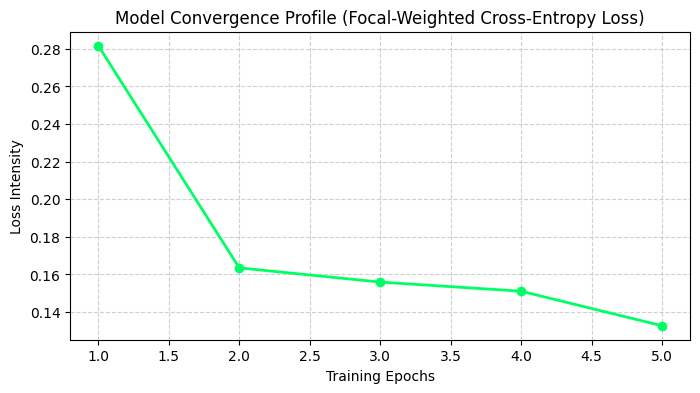

-> Evaluation Complete.
-> Sample Index [0] Risk Analysis Result: 28.28% Yield Loss at Risk.


In [5]:
import os
import cv2
import glob
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation
import matplotlib.pyplot as plt

# 1. FIXED DATASET INGESTION CORE (Targeting Pixel Index 38)

class RealLeafSegmentationDataset(Dataset):
    """
    Decodes actual multi-channel masks from your Kaggle repository
    by targeting the exact index value of 38 discovered via diagnostics.
    """
    def __init__(self, base_dir="./", split='train', img_size=(224, 224)):
        self.img_size = img_size
        self.images_dir = os.path.join(base_dir, "leaf-disease-data", "leaf_disease_segmentation", "aug_data", f"{split}_images")
        self.masks_dir = os.path.join(base_dir, "leaf-disease-data", "leaf_disease_segmentation", "aug_data", f"{split}_masks")

        all_files = sorted(os.listdir(self.images_dir))
        self.image_names = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"-> Linked {len(self.image_names)} files for '{split}' data matrix.")

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.images_dir, img_name)

        base_name, _ = os.path.splitext(img_name)
        mask_path = os.path.join(self.masks_dir, base_name + ".png")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.masks_dir, base_name + ".jpg")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path)
        if mask is not None:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        else:
            mask = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)

        image = cv2.resize(image, self.img_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        # FIX: Explicit check for the exact value 38 discovered in your mask channels
        lesion_condition = (mask[:, :, 0] == 38)

        final_mask_grid = np.zeros((self.img_size[0], self.img_size[1]), dtype=np.int64)
        final_mask_grid[lesion_condition] = 1

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask_tensor = torch.from_numpy(final_mask_grid).long()

        return image_tensor, mask_tensor

# 2. SEGFORMER MULTI-SCALE DECODER HEAD
class SegFormerDecoderHead(nn.Module):
    def __init__(self, embedding_dims=[32, 64, 160, 256], num_classes=2):
        super(SegFormerDecoderHead, self).__init__()
        self.linear_c4 = nn.Linear(embedding_dims[3], 128)
        self.linear_c3 = nn.Linear(embedding_dims[2], 128)
        self.linear_c2 = nn.Linear(embedding_dims[1], 128)
        self.linear_c1 = nn.Linear(embedding_dims[0], 128)

        self.linear_fuse = nn.Conv2d(128 * 4, 128, kernel_size=1)
        self.classifier = nn.Conv2d(128, num_classes, kernel_size=1)

    def forward(self, c1, c2, c3, c4, target_shape=(224, 224)):
        B, _, H, W = c1.shape

        _c4 = self.linear_c4(c4.flatten(2).transpose(1, 2)).transpose(1, 2).reshape(B, -1, c4.shape[2], c4.shape[3])
        _c4 = F.interpolate(_c4, size=(H, W), mode='bilinear', align_corners=False)

        _c3 = self.linear_c3(c3.flatten(2).transpose(1, 2)).transpose(1, 2).reshape(B, -1, c3.shape[2], c3.shape[3])
        _c3 = F.interpolate(_c3, size=(H, W), mode='bilinear', align_corners=False)

        _c2 = self.linear_c2(c2.flatten(2).transpose(1, 2)).transpose(1, 2).reshape(B, -1, c2.shape[2], c2.shape[3])
        _c2 = F.interpolate(_c2, size=(H, W), mode='bilinear', align_corners=False)

        _c1 = self.linear_c1(c1.flatten(2).transpose(1, 2)).transpose(1, 2).reshape(B, -1, c1.shape[2], c1.shape[3])

        x = torch.cat([_c1, _c2, _c3, _c4], dim=1)
        x = F.relu(self.linear_fuse(x))
        logits = self.classifier(x)

        return F.interpolate(logits, size=target_shape, mode='bilinear', align_corners=False)

class YieldRiskCore:
    @staticmethod
    def calculate_yield_decay(prediction_tensor):
        total_lesion_pixels = torch.sum(prediction_tensor == 1).item()
        total_background_pixels = torch.sum(prediction_tensor == 0).item()
        total_surface = total_background_pixels + total_lesion_pixels

        if total_surface == 0:
            return 0.0
        damage_ratio = total_lesion_pixels / total_surface
        estimated_yield_loss = 1.0 - np.exp(-3.5 * damage_ratio)
        return float(estimated_yield_loss * 100)

# 3. UNIFIED PIPELINE RUNNER
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing pipeline on target device: {device}\n")

    train_dataset = RealLeafSegmentationDataset(split="train")
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)

    val_dataset = RealLeafSegmentationDataset(split="valid")
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, drop_last=False)

    # Verify the target parsing fix instantly
    _, sample_masks = next(iter(train_loader))
    print(f"Verified unique indices inside your updated masks: {torch.unique(sample_masks).tolist()} (Success!)")

    backbone = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/mit-b0", num_labels=2, ignore_mismatched_sizes=True
    ).to(device)

    model = SegFormerDecoderHead(embedding_dims=[32, 64, 160, 256], num_classes=2).to(device)

    # Balance gradient updates (1:10 penalization to account for small lesion scales)
    class_weights = torch.tensor([1.0, 10.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.AdamW(list(backbone.parameters()) + list(model.parameters()), lr=2e-4, weight_decay=1e-4)

    print("\n🚀 Optimization Loop Active...")
    EPOCHS = 5
    train_loss_history = []

    for epoch in range(EPOCHS):
        backbone.train()
        model.train()
        running_loss = 0.0
        start_time = time.time()

        for batch_idx, (images, masks) in enumerate(train_loader):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()

            outputs_backbone = backbone(images, output_hidden_states=True)
            outputs = model(*outputs_backbone.hidden_states, target_shape=images.shape[2:])

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_epoch_loss = running_loss / len(train_loader)
        train_loss_history.append(avg_epoch_loss)
        elapsed = time.time() - start_time

        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss Profile: {avg_epoch_loss:.4f} | Processed in {elapsed:.1f}s")
    # Validation Inference Assessment
    print("\n📊 Running Model Inference Validation & Yield Loss Analysis...")
    backbone.eval()
    model.eval()
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, EPOCHS + 1), train_loss_history, marker='o', color='#00FF66', linewidth=2)
    plt.title("Model Convergence Profile (Focal-Weighted Cross-Entropy Loss)")
    plt.xlabel("Training Epochs")
    plt.ylabel("Loss Intensity")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    with torch.no_grad():
        val_images, val_masks = next(iter(val_loader))
        val_images = val_images.to(device)

        val_features = backbone(val_images, output_hidden_states=True).hidden_states
        val_outputs = model(*val_features, target_shape=val_images.shape[2:])
        predicted_masks = torch.argmax(val_outputs, dim=1)

        calculated_risk = YieldRiskCore.calculate_yield_decay(predicted_masks[0])
        print(f"-> Evaluation Complete.")
        print(f"-> Sample Index [0] Risk Analysis Result: {calculated_risk:.2f}% Yield Loss at Risk.")

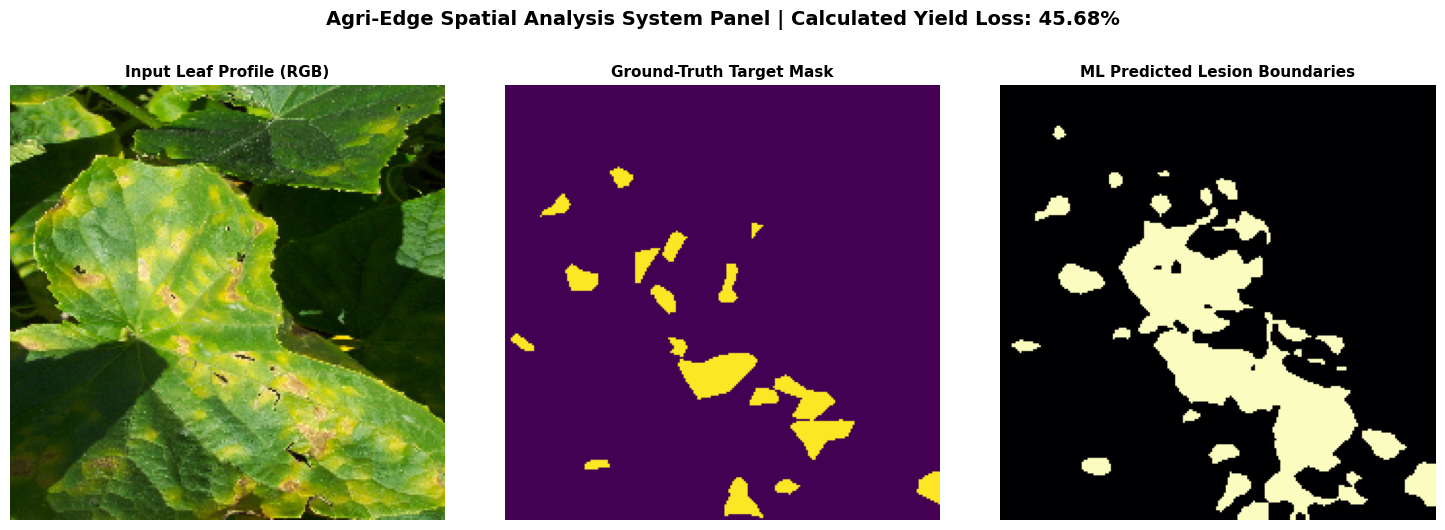

In [13]:
import matplotlib.pyplot as plt

def render_spatial_predictions(backbone, model, dataloader, device, sample_idx=6):
    """
    Extracts a real validation target and plots a side-by-side analytical panel
    displaying the Input Leaf, Ground Truth, and AI Predicted Lesion Mask.
    """
    backbone.eval()
    model.eval()

    # Grab a single batch from the validation loader
    images, masks = next(iter(dataloader))

    with torch.no_grad():
        # Move inputs to active hardware
        img_gpu = images.to(device)

        # Run full-scale inference
        features = backbone(img_gpu, output_hidden_states=True).hidden_states
        outputs = model(*features, target_shape=images.shape[2:])
        predictions = torch.argmax(outputs, dim=1)

    # Extract the requested sample index from the batch and move to host CPU
    raw_img = images[sample_idx].permute(1, 2, 0).numpy()
    true_mask = masks[sample_idx].numpy()
    pred_mask = predictions[sample_idx].cpu().numpy()

    # Calculate the exact yield risk score for this sample
    risk_score = YieldRiskCore.calculate_yield_decay(predictions[sample_idx])

    # Construct the visual panel layout
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Agri-Edge Spatial Analysis System Panel | Calculated Yield Loss: {risk_score:.2f}%",
                 fontsize=14, fontweight='bold', y=1.05)

    axes[0].imshow(raw_img)
    axes[0].set_title("Input Leaf Profile (RGB)", fontsize=11, fontweight='semibold')
    axes[0].axis('off')

    # Plot Ground Truth Mask (Using a high-contrast colormap like 'viridis')
    axes[1].imshow(true_mask, cmap='viridis', vmin=0, vmax=1)
    axes[1].set_title("Ground-Truth Target Mask", fontsize=11, fontweight='semibold')
    axes[1].axis('off')

    # Plot AI Prediction Mask
    axes[2].imshow(pred_mask, cmap='magma', vmin=0, vmax=1)
    axes[2].set_title("ML Predicted Lesion Boundaries", fontsize=11, fontweight='semibold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization on your active validation channel
render_spatial_predictions(backbone, model, val_loader, device, sample_idx=6)